# 1. Data Loading & Initial Exploration

In [1]:
import pandas as pd

path = "../data/Sample - Superstore.csv"

df = pd.read_csv(path, encoding='ISO-8859-1')
# Display the first few rows of the DataFrame
df.head()
# Display the number of columns and rows in the DataFrame
df.shape
# Display the data types of each column in the DataFrame
df.info()
# Display the number of duplicate rows and the number of null values in each column
df.duplicated().sum()
df.isnull().sum()



<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# 2. Data Cleaning

In [2]:
# Convert the 'Order Date' and 'Ship Date' columns to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.info()
# Check for negative values in the 'Sales', 'Quantity', and 'Profit' columns
sales_check = print((df['Sales'] <= 0).sum())
quantity_neg = print((df['Quantity'] < 0).sum())
profit_neg = print((df['Profit'] < 0).sum())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

# 3. Business Analysis

## Revenue Analysis by City

### Key Insights from Top 10 Cities Analysis:

1. **New York City & Los Angeles Dominance 🌆:** **New York City** ($256.3k) and **Los Angeles** ($175.8k) are the primary drivers of corporate revenue. Together, they account for a massive share of total sales, indicating high market concentration and strong brand dependence on these two major metropolitan hubs.
2. **The Mid-Tier Clusters:** Cities like **Seattle**, **San Francisco**, and **Philadelphia** form a highly consistent secondary tier, each generating between $109k and $119k. Maintaining marketing and sales efforts in these regions ensures a diversified revenue stream.
3. **Strategic Expansion Opportunities:** The lower end of the Top 10 (e.g., **Jacksonville** and **Springfield** at ~$44k) shows steady traction. These cities represent potential targets for localized promotional campaigns to scale up lower-performing but promising regional branches.

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


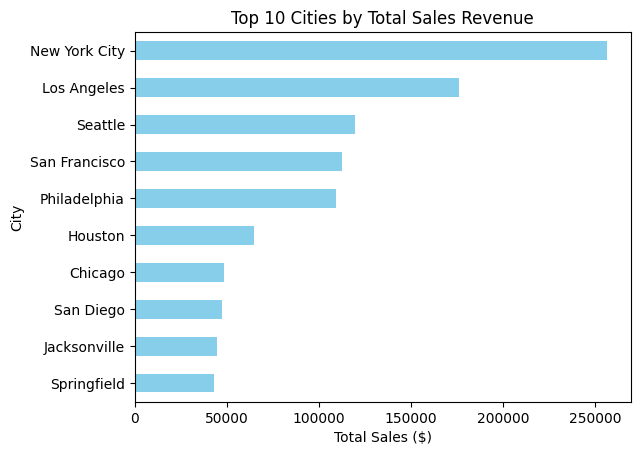

In [3]:
import matplotlib.pyplot as plt
# Calculate the total sales revenue for each city and sort the results in descending order
revenue = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
print(revenue)
#New York City dominates revenue generation, suggesting strong market dependence.”
# Visualize the top 10 cities by total sales revenue using a horizontal bar chart
revenue.plot(kind='barh', color='skyblue')
plt.title('Top 10 Cities by Total Sales Revenue')
plt.xlabel('Total Sales ($)')
plt.ylabel('City')
plt.gca().invert_yaxis() 
plt.show()




## Top 10 customers by sales

### Key Insights from Top 10 Customers Analysis:

1. **The Sean Miller Profitability Paradox 🚨:** While **Sean Miller** is our absolute top customer by sales volume, generating a massive **$25,043** in revenue, he represents a major financial leak with a net loss of **-$1,980.74**. This suggests deep operational or pricing inefficiencies, such as unsustainable discounting strategies or high product return costs, requiring immediate account evaluation.
2. **High-Value MVP Customer 🏆:** **Tamara Chand** stands out as the most profitable customer. Generating **$19,052** in sales with an outstanding net profit of **$8,981.32**, she yields a remarkable profit margin of nearly **47%**. Retaining customers with this buying profile is critical for bottom-line growth.
3. **Transaction Efficiency (Volume vs. Value):** Comparing **Ken Lonsdale** and **Tom Ashbrook** reveals distinct purchasing behaviors:
   * *Ken Lonsdale* requires high operational overhead with **29 separate orders** to reach $14.1k in sales.
   * *Tom Ashbrook* is highly cost-efficient, generating **$14.5k in sales across just 10 orders**. 
   * Low-frequency, high-value buyers generally minimize shipping and processing logistics costs, significantly preserving profit margins.

In [4]:
# Analyze the top 10 customers by total sales revenue, total profit, and total number of orders
customer_analysis = df.groupby('Customer Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'count')
).sort_values(ascending=False, by='Total_Sales').head(10)
customer_analysis


,Total_Sales,Total_Profit,Total_Orders
Customer Name,,,
Sean Miller,25043.050,-1980.7393,15
Tamara Chand,19052.218,8981.3239,12
Raymond Buch,15117.339,6976.0959,18
Tom Ashbrook,14595.620,4703.7883,10
Adrian Barton,14473.571,5444.8055,20
Ken Lonsdale,14175.229,806.8550,29
Sanjit Chand,14142.334,5757.4119,22
Hunter Lopez,12873.298,5622.4292,11
Sanjit Engle,12209.438,2650.6769,19


## Most profitable category

### Key Insights from Product Category Analysis:

1. **Technology Wins on Profitability (MVP):** While *Technology* leads in total sales ($836.1k), its real strength lies in its net profit, generating an impressive **$145.4k**. It holds the highest profit margin among all categories (~17.4%), making it the most lucrative segment for the business.
2. **Office Supplies is the Volume Engine:** *Office Supplies* has the lowest sales volume in dollars ($719k) but drives the vast majority of customer transactions with **6,026 total orders** (nearly triple the other categories). It generates a highly efficient and stable profit of **$122.5k** with a solid ~17% profit margin.
3. **The Furniture "Revenue Trap" 🚨:** *Furniture* represents a major operational inefficiency. It brings in massive top-line revenue ($741.9k, outperforming Office Supplies), but yields a critically low net profit of just **$18.4k**. This results in an unsustainable **2.4% profit margin**, likely due to high shipping/logistics costs or aggressive discounting strategies that clear inventory but destroy profitability.

In [5]:
# Analyze the performance of each product category by calculating total sales revenue, total profit, and total number of orders for each category
category_analysis = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'count')
).sort_values(ascending=False, by='Total_Profit')
category_analysis
# The Technology category is the most profitable, generating $14,9k in profit.

,Total_Sales,Total_Profit,Total_Orders
Category,,,
Technology,836154.0330,145454.9481,1847
Office Supplies,719047.0320,122490.8008,6026
Furniture,741999.7953,18451.2728,2121


## Monthly revenue trend

### Key Insights from Monthly Revenue Trend:

1. **Strong Year-End Seasonality (Q4 Spike):** Revenue consistently peaks during the fourth quarter (November and December). In 2014, November reached ~$78.6k, driven by holiday shopping and promotional events like Black Friday.
2. **September Performance Surge:** There is a recurring sharp increase every September (reaching $81.7k in 2014). This is likely correlated with "Back-to-School" campaigns and corporate restocking after the summer period.
3. **Post-Holiday Slump (Q1 Lows):** January and February represent the lowest revenue periods of the year (with February 2014 dropping to a baseline of $4.5k), showing a typical post-holiday drop in consumer spending.
4. **Positive Long-Term Growth:** The business displays a healthy Year-over-Year (YoY) upward trend, as the revenue peaks in 2016 and 2017 consistently outperform the baseline set in 2014.

Year_Month
2014-01    14236.8950
2014-02     4519.8920
2014-03    55691.0090
2014-04    28295.3450
2014-05    23648.2870
2014-06    34595.1276
2014-07    33946.3930
2014-08    27909.4685
2014-09    81777.3508
2014-10    31453.3930
2014-11    78628.7167
2014-12    69545.6205
Name: Sales, dtype: float64


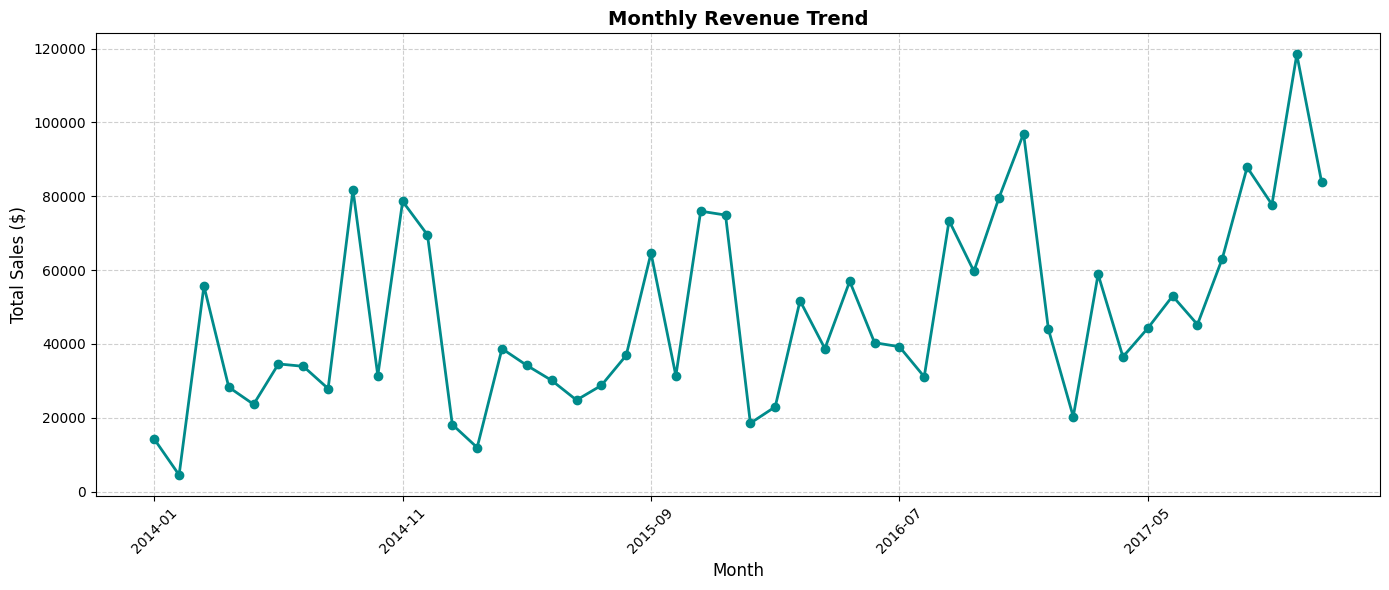

In [6]:
# Create a new column 'Year_Month' to represent the year and month of each order
df['Year_Month'] = df['Order Date'].dt.to_period('M')

# Calculate total sales revenue for each month
monthly_revenue = df.groupby('Year_Month')['Sales'].sum()

# Convert the PeriodIndex to string for better visualization
monthly_revenue.index = monthly_revenue.index.astype(str)

print(monthly_revenue.head(12))

# Visualize the monthly revenue trend using a line chart
plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='line', marker='o', color='darkcyan', linewidth=2)

plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) 
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

# 4. KPI Overview


## Total Revenue

### 💰 Key Performance Indicator: Total Revenue

**Total Sales Revenue:** `$2,297,200.86` (~$2.3M)

#### Executive Insights & Business Context:
* **Strong Market Traction:** Reaching a milestone of **$2.3 million** in total sales demonstrates robust market demand and a solid, established customer base across our operating regions.
* **Volume vs. Profitability:** While this top-line revenue figure is highly impressive, our deeper segment analysis reveals that it is heavily driven by lower-margin categories (like *Furniture*) and high-volume, low-value transactions (like *Office Supplies*). 
* **Strategic Outlook:** To sustain and improve this revenue stream, the company should shift its focus from purely chasing sales volume to optimizing high-margin categories (like *Technology*) and adjusting pricing/discount structures for low-profit accounts.

In [7]:
Total_revenue = df['Sales'].sum()
print(f"Total Revenue: ${Total_revenue:,.2f}")



Total Revenue: $2,297,200.86


# Total Profit

### 📈 Key Performance Indicator: Total Net Profit

**Total Net Profit:** `$286,397.02`

#### Executive Insights & Business Context:
* **Healthy Overall Baseline:** A total net profit of **$286.4k** on $2.29M in sales indicates an overall healthy business with a consolidated **Profit Margin of 12.47%**. The company is fundamentally viable and generating solid returns.
* **The Hidden Risk (Profit Concentration):** Although the total profit looks strong, our deep-dive analysis reveals a dangerous imbalance. Nearly **93% of this profit** comes from just two categories (*Technology* and *Office Supplies*), while *Furniture* absorbs immense operational costs and returns almost zero bottom-line value.
* **Strategic Outlook:** To expand this net profit without necessarily increasing sales costs, management must optimize low-performing sectors. Raising the profit margin of *Furniture* even by a few percentage points or eliminating bleeding customer accounts (like *Sean Miller*) will directly skyrocket the total net profit.

In [8]:
Total_profit = df['Profit'].sum()
print(f"Total Profit: ${Total_profit:,.2f}")

Total Profit: $286,397.02


# Profit Margin

### 🎯 Key Performance Indicator: Overall Profit Margin

**Overall Profit Margin:** `12.47%`

#### Executive Insights & Business Context:
* **Benchmark & Efficiency:** A **12.47%** profit margin is a solid and healthy baseline for a retail/superstore model. It proves that the company has a stable pricing structure and generally manages to cover its cost of goods sold (COGS) and operational expenses effectively.
* **The Efficiency Gap:** While 12.47% is a good average, it hides the massive contrast between our product segments. Our data shows that *Technology* and *Office Supplies* operate at a highly efficient **~17% margin**, while *Furniture* drags the company average down by operating at a critically low **2.4% margin**.
* **Strategic Outlook:** Management should set a corporate target to push the overall margin from 12.47% to **15%**. This can be achieved not by selling more items, but through tactical decisions: limiting deep discounts on low-margin furniture, optimizing delivery logistics for bulky items, and shifting marketing budgets toward high-margin technology products.

In [9]:
overall_margin = (Total_profit / Total_revenue) * 100
print(f"Overall Margin: {overall_margin:.2f}%")

Overall Margin: 12.47%


Markdown
---

## 💾 Data Export: Saving the Cleaned Dataset

Now that the initial data preparation, cleaning, and foundational KPI metrics are established, we will export this finalized version of the DataFrame. 

The cleaned dataset will be saved as a CSV file inside the `outputs/` directory for use in subsequent

In [10]:
import os

# Find the current working directory
current_dir = os.getcwd()

# Move up one level to the parent directory
current_dir = os.path.dirname(current_dir)

# Construct the output path for the cleaned dataset
output_path = os.path.join(current_dir, 'outputs', 'cleaned_dataset.csv')

# Save the cleaned dataset to a new CSV file in the outputs folder
df.to_csv(output_path, index=False)
